In [ ]:
# Instalamos trimesh (con dependencias 'easy' para carga robusta), open3d y pandas
!pip install trimesh[easy] open3d pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempti

In [14]:
import os
from google.colab import files
import shutil

# Crear carpeta de trabajo
os.makedirs("media", exist_ok=True)
os.makedirs("convertidos", exist_ok=True)

print("📂 Sube tus archivos (.obj, .stl, .gltf):")
uploaded = files.upload()

# Mover archivos subidos a la carpeta 'media' para mantener orden
for filename in uploaded.keys():
    ruta_destino = os.path.join("media", filename)
    shutil.move(filename, ruta_destino)
    print(f"✅ Archivo guardado en: {ruta_destino}")

📂 Sube tus archivos (.obj, .stl, .gltf):



⚙️ Procesando 3 modelos correctos...

🔹 Analizando: eyeball.obj ...
   ✅ Convertido a OBJ en carpeta /convertidos
🔹 Analizando: eyeball.stl ...
   ✅ Convertido a OBJ en carpeta /convertidos
🔹 Analizando: Duck.glb ...
   ✅ Convertido a OBJ en carpeta /convertidos


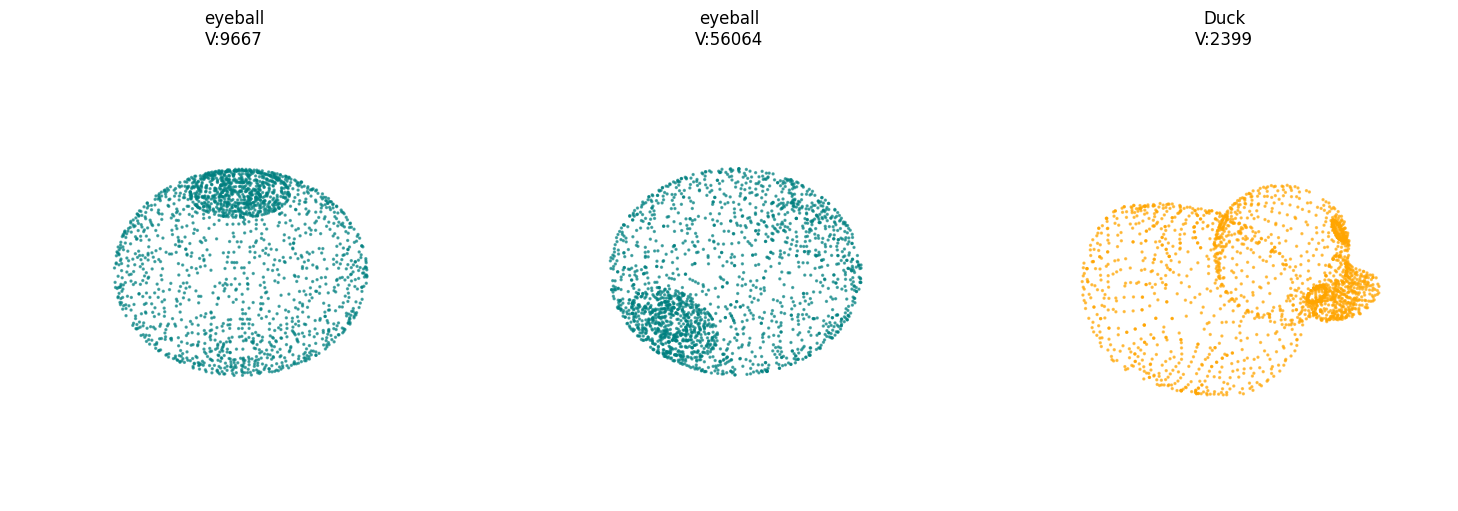


📊 --- COMPARATIVA FINAL ---


,Archivo,Tipo,Vértices,Caras,Duplicados,Watertight
0,eyeball.obj,.obj,9667,18688,0,False
1,eyeball.stl,.stl,56064,18688,46397,False
2,Duck.glb,.glb,2399,4212,291,False


In [15]:
import os
import trimesh
import open3d as o3d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# 1. LIMPIEZA Y PREPARACIÓN
# ---------------------------------------------------------
carpeta_media = "media"
os.makedirs(carpeta_media, exist_ok=True)
os.makedirs("convertidos", exist_ok=True)

# 2. DESCARGAR UN MODELO GLB DE PRUEBA (Pato)
# ---------------------------------------------------------
# Usamos un .glb porque contiene todo en un solo archivo (no pide .bin)
url_pato = "https://raw.githubusercontent.com/KhronosGroup/glTF-Sample-Models/master/2.0/Duck/glTF-Binary/Duck.glb"
ruta_pato = os.path.join(carpeta_media, "Duck.glb")

if not os.path.exists(ruta_pato):
    print("⬇️ Descargando modelo de prueba (Duck.glb)...")
    response = requests.get(url_pato)
    with open(ruta_pato, 'wb') as f:
        f.write(response.content)

# 3. SCRIPT DE ANÁLISIS Y CONVERSIÓN
# ---------------------------------------------------------
def procesar_modelos():
    archivos = [f for f in os.listdir(carpeta_media) if f.lower().endswith(('.obj', '.stl', '.glb', '.gltf'))]

    if not archivos:
        print("❌ No hay archivos para analizar.")
        return

    datos = []
    print(f"\n⚙️ Procesando {len(archivos)} modelos correctos...\n")

    fig = plt.figure(figsize=(15, 5))

    for i, archivo in enumerate(archivos):
        ruta = os.path.join(carpeta_media, archivo)
        nombre, ext = os.path.splitext(archivo)

        print(f"🔹 Analizando: {archivo} ...")

        # --- A. CARGA CON TRIMESH ---
        try:
            # force='mesh' es vital para convertir escenas (GLB/GLTF) a una sola malla
            mesh = trimesh.load(ruta, force='mesh', process=False)
        except Exception as e:
            print(f"   ⚠️ Saltando archivo corrupto: {e}")
            continue

        # Datos
        n_verts = mesh.vertices.shape[0]
        n_faces = mesh.faces.shape[0]

        # Detectar duplicados (vértices compartidos)
        unique_v = np.unique(mesh.vertices, axis=0)
        duplicados = n_verts - len(unique_v)

        datos.append({
            "Archivo": archivo,
            "Tipo": ext,
            "Vértices": n_verts,
            "Caras": n_faces,
            "Duplicados": duplicados,
            "Watertight": mesh.is_watertight
        })

        # --- B. VISUALIZACIÓN ---
        ax = fig.add_subplot(1, len(archivos), i + 1, projection='3d')
        # Muestreo de puntos si es muy pesado
        puntos = mesh.vertices
        if n_verts > 2000:
            idx = np.random.choice(n_verts, 2000, replace=False)
            puntos = puntos[idx]

        colores = 'orange' if 'Duck' in archivo else 'teal'
        ax.scatter(puntos[:,0], puntos[:,1], puntos[:,2], s=2, c=colores, alpha=0.6)
        ax.set_title(f"{nombre}\nV:{n_verts}")
        ax.axis('off')

        # --- C. CONVERSIÓN ---
        # Convertimos todo a OBJ para estandarizar
        ruta_salida = os.path.join("convertidos", f"{nombre}_exportado.obj")
        mesh.export(ruta_salida)
        print(f"   ✅ Convertido a OBJ en carpeta /convertidos")

    plt.tight_layout()
    plt.show()

    # --- D. TABLA FINAL ---
    print("\n📊 --- COMPARATIVA FINAL ---")
    df = pd.DataFrame(datos)
    display(df)

# EJECUTAR
procesar_modelos()

🎬 Generando GIFs para 3 modelos...

🎥 Renderizando: eyeball.obj ...
📽  Video file gifs_salida/eyeball.gif is open... recalculated fps: 10💾 saved to gifs_salida/eyeball.gif
✅ GIF guardado: gifs_salida/eyeball.gif


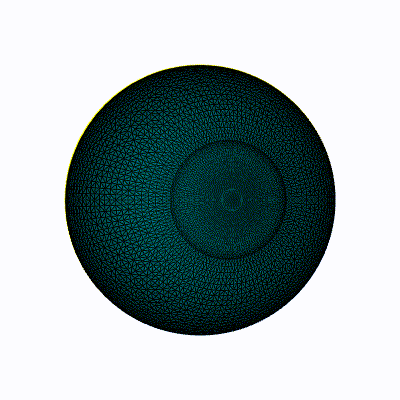

----------------------------------------
🎥 Renderizando: eyeball.stl ...
📽  Video file gifs_salida/eyeball.gif is open... recalculated fps: 10💾 saved to gifs_salida/eyeball.gif
✅ GIF guardado: gifs_salida/eyeball.gif


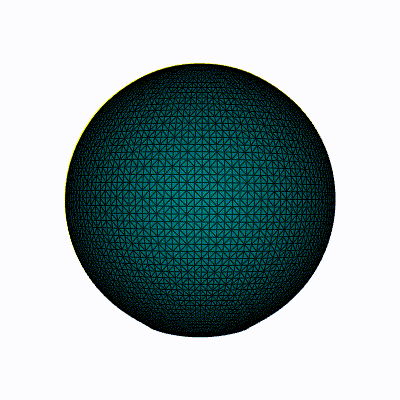

----------------------------------------
🎥 Renderizando: Duck.glb ...
📽  Video file gifs_salida/Duck.gif is open... recalculated fps: 10💾 saved to gifs_salida/Duck.gif
✅ GIF guardado: gifs_salida/Duck.gif


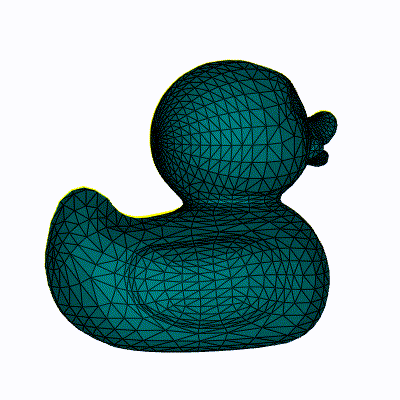

----------------------------------------


In [16]:
import os
import trimesh
import vedo
import numpy as np
from IPython.display import Image, display

# 1. CONFIGURACIÓN DE VEDO PARA COLAB
# ---------------------------------------------------------
# 'vtk' permite renderizado por software (sin tarjeta gráfica dedicada)
vedo.settings.default_backend = 'vtk'
vedo.settings.screenshot_transparent_background = False

def generar_gifs_rotatorios(carpeta_origen="media"):
    archivos = [f for f in os.listdir(carpeta_origen) if f.lower().endswith(('.obj', '.stl', '.glb', '.gltf'))]

    if not archivos:
        print("❌ No hay archivos en la carpeta 'media'.")
        return

    print(f"🎬 Generando GIFs para {len(archivos)} modelos...\n")

    # Crear carpeta para guardar los gifs
    os.makedirs("gifs_salida", exist_ok=True)

    for archivo in archivos:
        ruta_completa = os.path.join(carpeta_origen, archivo)
        nombre_base = os.path.splitext(archivo)[0]
        nombre_gif = f"gifs_salida/{nombre_base}.gif"

        # -----------------------------------------------------
        # A. CARGA SEGURA CON TRIMESH
        # -----------------------------------------------------
        try:
            # force='mesh': Convierte escenas complejas en una sola malla
            # process=False: Evita el error de Numpy 2.0
            t_mesh = trimesh.load(ruta_completa, force='mesh', process=False)
        except Exception as e:
            print(f"⚠️ Saltando {archivo}: Archivo corrupto o incompleto.")
            continue

        print(f"🎥 Renderizando: {archivo} ...")

        # -----------------------------------------------------
        # B. PREPARACIÓN VISUAL (VEDO)
        # -----------------------------------------------------
        # Convertimos de Trimesh a Vedo
        mesh = vedo.Mesh(t_mesh)

        # Estética: Color turquesa metalizado con aristas negras
        mesh.c("teal").lighting("plastic").lw(0.1)

        # Centrar la cámara en el objeto
        mesh.center_of_mass()

        # Crear el Plotter (el lienzo invisible)
        # size: Tamaño del GIF en pixeles
        plt = vedo.Plotter(offscreen=True, size=(400, 400), bg="white")

        # Añadimos el objeto al plotter
        plt.show(mesh, zoom=1.2)

        # -----------------------------------------------------
        # C. ANIMACIÓN Y GUARDADO
        # -----------------------------------------------------
        # backend='ffmpeg' es clave para que funcione en Colab
        video = vedo.Video(nombre_gif, duration=3, backend='ffmpeg', fps=15)

        # Bucle de rotación (360 grados en 30 frames aprox)
        for _ in range(30):
            mesh.rotate_y(12) # Rotar 12 grados por frame
            plt.render()      # Actualizar imagen
            video.add_frame() # Guardar foto en el video

        video.close() # Cerrar y guardar archivo final

        # -----------------------------------------------------
        # D. MOSTRAR RESULTADO
        # -----------------------------------------------------
        print(f"✅ GIF guardado: {nombre_gif}")
        display(Image(filename=nombre_gif))
        print("-" * 40)

# EJECUTAR FUNCIÓN
generar_gifs_rotatorios()